# PCA on the decathlon dataset

Reproduces the canonical FactoMineR PCA example.

In [1]:
import matplotlib.pyplot as plt
from factominer import PCA, HCPC, dimdesc
from factominer.datasets import load_decathlon

df = load_decathlon()
df.head()

,100m,Long.jump,Shot.put,High.jump,400m,110m.hurdle,Discus,Pole.vault,Javeline,1500m,Rank,Points,Competition
SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7,1,8217,Decastar
CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5,2,8122,Decastar
KARPOV,11.02,7.30,14.77,2.04,48.37,14.09,48.95,4.92,50.31,300.2,3,8099,Decastar
BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1,4,8067,Decastar
YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.4,5,8036,Decastar


In [2]:
res = PCA(df, scale_unit=True, ncp=5,
          quanti_sup=["Rank", "Points"],
          quali_sup=["Competition"])
print(res.summary())


Results for the PCA

Eigenvalues
--------------------------------------------------
        eigenvalue  percentage of variance  cumulative percentage of variance
comp 1      3.2719                 32.7191                            32.7191
comp 2      1.7371                 17.3713                            50.0904
comp 3      1.4049                 14.0492                            64.1395
comp 4      1.0569                 10.5685                            74.7080
comp 5      0.6848                  6.8477                            81.5558

Individuals (the first 5 are reported)
--------------------------------------------------
            Dim.1   Dim.2   Dim.3   Dim.4   Dim.5
SEBRLE     0.7916  0.7716  0.8268  1.1746 -0.7072
CLAY       1.2350  0.5746  2.1412 -0.3548  1.9746
KARPOV     1.3582  0.4840  1.9563 -1.8565 -0.7952
BERNARD   -0.6095 -0.8746  0.8899  2.2206 -0.3616
YURKOV    -0.5860  2.1310 -1.2252  0.8736 -1.2514
WARNERS    0.3569 -1.6850  0.7666 -0.5893 -1.0017
ZSIVOC

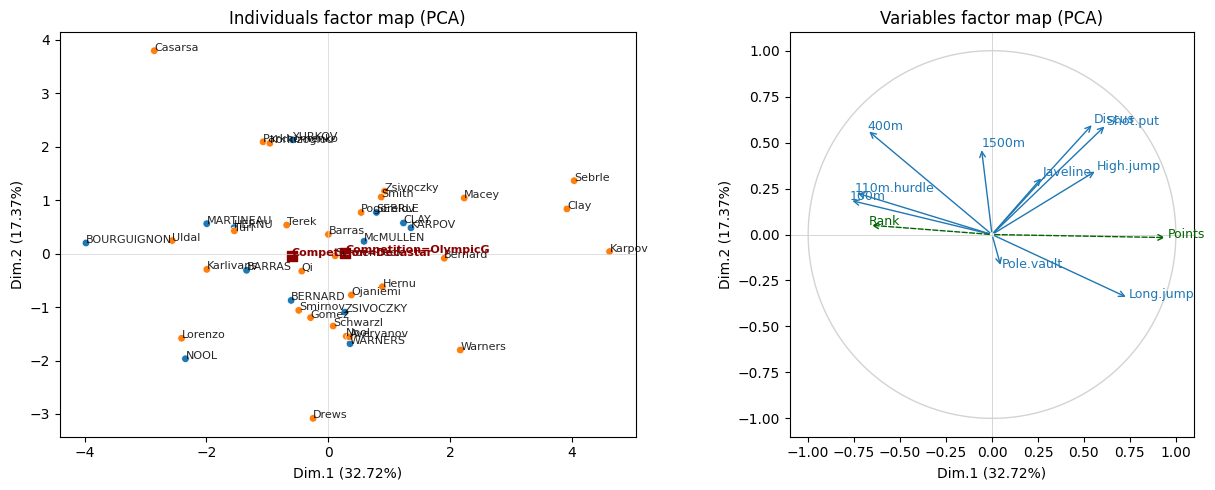

In [3]:
from factominer.plot import plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot(res, choix="ind", habillage="Competition", ax=axes[0])
plot(res, choix="var", ax=axes[1])
plt.tight_layout()
plt.show()

In [4]:
desc = dimdesc(res, axes=[0, 1])
desc[0].get("quanti", "no quanti").head() if hasattr(desc[0].get("quanti", None), 'head') else desc[0]

,correlation,p.value
variable,,
Points,0.956154,0.000000e+00
100m,-0.774720,2.778467e-09
110m.hurdle,-0.746245,2.136962e-08
Long.jump,0.741900,2.849886e-08
400m,-0.679610,1.028175e-06


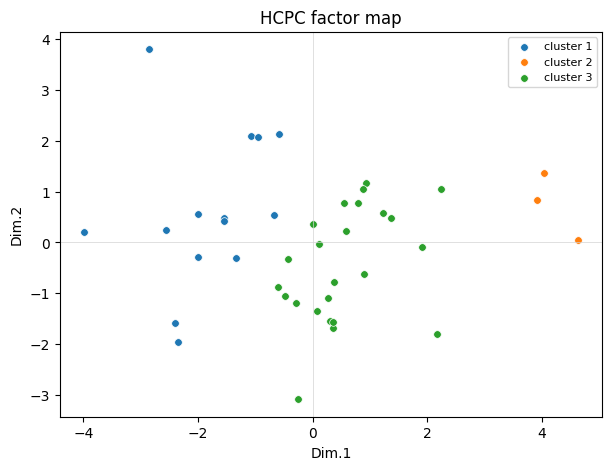

In [5]:
clust = HCPC(res, nb_clust=3)
fig, ax = plt.subplots(figsize=(7, 5))
plot(clust, choix="factor_map", ax=ax)
plt.show()